In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

filename = '/home/sgomgon/TFM_IMT/resultados/test.csv'

In [29]:
df = pd.read_csv(filename)
prefix = df[df['metodo'] == 'prefix']
segment = df[df['metodo'] == 'segment']
new_df = pd.merge(prefix,segment, on=['modelo','src','trg','bleu','ter'], suffixes=('_pref','_seg'))
new_df.drop(columns=['observaciones_pref','observaciones_seg', 'metodo_pref', 'metodo_seg'], inplace=True)
new_df.columns

Index(['modelo', 'src', 'trg', 'bleu', 'ter', 'wsr_pref', 'mar_pref',
       'wsr_seg', 'mar_seg'],
      dtype='object')

In [30]:
lang_filter = ['gl','ca','sw']
new_df = new_df[new_df['src'].isin(lang_filter) | new_df['trg'].isin(lang_filter)]

In [31]:
def get_mean(df, lang, col):
    values = df[(df['src'] == lang) | (df['trg'] == lang)][col]
    return values.mean(), values.std()
new_df['dif_mar'] = new_df['mar_seg'] - new_df['mar_pref']
new_df['dif_wsr'] = new_df['wsr_seg'] - new_df['wsr_pref']

print('Diferencia MAR (segment - prefix):')
for lang in new_df['src'].unique():
    mean_mar, std_mar = get_mean(new_df, lang, 'dif_mar')
    print(f'\t{lang}: {mean_mar:.4f} ± {std_mar:.4f}')
print('Diferencia WSR (segment - prefix):')
for lang in new_df['src'].unique():
    mean_wsr, std_wsr = get_mean(new_df, lang, 'dif_wsr')
    print(f'\t{lang}: {mean_wsr:.4f} ± {std_wsr:.4f}')

Diferencia MAR (segment - prefix):
	en: 0.3369 ± 0.1228
	gl: 0.3008 ± 0.0658
	sw: 0.3160 ± 0.1345
	ca: 0.4725 ± 0.1298
Diferencia WSR (segment - prefix):
	en: -0.2131 ± 0.1510
	gl: -0.2405 ± 0.1710
	sw: -0.1977 ± 0.1321
	ca: -0.1778 ± 0.1493


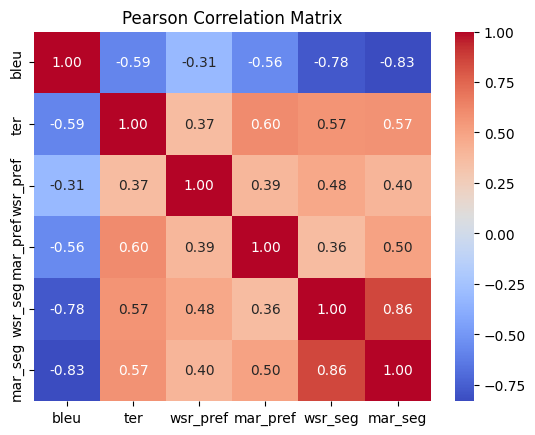

In [32]:
drop_cols = ['modelo','src','trg', 'dif_mar', 'dif_wsr']
drop_df = new_df.drop(columns=drop_cols)
corr_matrix = drop_df.corr(method='pearson')

plt.figure()
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

In [33]:
corr_matrix

,bleu,ter,wsr_pref,mar_pref,wsr_seg,mar_seg
bleu,1.000000,-0.587892,-0.313120,-0.564858,-0.777243,-0.831702
ter,-0.587892,1.000000,0.369584,0.604413,0.569762,0.570880
wsr_pref,-0.313120,0.369584,1.000000,0.393015,0.477597,0.404813
mar_pref,-0.564858,0.604413,0.393015,1.000000,0.363982,0.501538
wsr_seg,-0.777243,0.569762,0.477597,0.363982,1.000000,0.855694
mar_seg,-0.831702,0.570880,0.404813,0.501538,0.855694,1.000000
